<a href="https://colab.research.google.com/github/ivan-penta/proyecto_cidam/blob/main/proyecto_cidam_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Entorno Pyspark

In [1]:
# 1. Instalar Java 17 y PySpark
!apt-get update -qq
!apt-get install openjdk-17-jdk -y
!pip install pyspark==4.0.1 -q

# 2. Configurar variables de entorno
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

# 3. Verificar instalación de Java
!java -version

# 4. Crear SparkSession
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Analisis Compranet Big Data") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.driver.maxResultSize", "4g") \
    .getOrCreate()

print("✅ SparkSession creada")
print("Versión:", spark.version)
print("App Name:", spark.sparkContext.appName)
print("Master:", spark.sparkContext.master)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
openjdk-17-jdk is already the newest version (17.0.18+8-1~22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 22 not upgraded.
openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
✅ SparkSession creada
Versión: 4.0.1
App Name: Analisis Compranet Big Data
Master: local[*]


### Cargar dataset

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, expr

spark = SparkSession.builder \
    .appName("Analisis Compranet Big Data") \
    .getOrCreate()

print("📂 Cargando dataset completo de CompraNet...")


data = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("multiLine", "true") \
    .option("escape", "\"") \
    .csv("compranet_historico.csv")

data = data.withColumn(
    "importe",
    expr("try_cast(importe as double)")
)

conteo_nulos = data.filter(col("importe").isNull()).count()
print(f"⚠️ Registros con formato inválido convertidos a NULL: {conteo_nulos}")

total_registros = data.count()
print(f"📊 Total de registros procesados: {total_registros:,}")

data.write.mode("overwrite").parquet("compranet_historico.parquet")
print("💾 Dataset completo guardado exitosamente en formato Parquet.")

📂 Cargando dataset completo de CompraNet...
⚠️ Registros con formato inválido convertidos a NULL: 5188
📊 Total de registros procesados: 2,356,612
💾 Dataset completo guardado exitosamente en formato Parquet.


### Limpieza de nulos

In [3]:
from pyspark.sql.functions import col

registros_antes = data.count()

data = data.dropna(subset=[
    "importe",
    "ff_fecha_inicio",
    "ff_fecha_fin"
])

registros_despues = data.count()
print(f"Registros antes de limpieza: {registros_antes:,}")
print(f"Registros después de limpieza: {registros_despues:,}")
print(f"Registros eliminados: {registros_antes - registros_despues:,}")

Registros antes de limpieza: 2,356,612
Registros después de limpieza: 2,347,566
Registros eliminados: 9,046


### Selección de variables

In [4]:
from pyspark.sql.functions import col

df = data.select(
    "codigo_contrato",
    "codigo_expediente",
    "proveedor",
    "contract_type",
    "tipo_contratacion",
    "tipo_expediente",
    "importe",
    "moneda",
    "fecha_inicio",
    "fecha_fin"
)

df.show(5)

+---------------+-----------------+--------------------+---------------+--------------------+--------------------+----------+------+--------------------+--------------------+
|codigo_contrato|codigo_expediente|           proveedor|  contract_type|   tipo_contratacion|     tipo_expediente|   importe|moneda|        fecha_inicio|           fecha_fin|
+---------------+-----------------+--------------------+---------------+--------------------+--------------------+----------+------+--------------------+--------------------+
|        2376191|          2161394|Equity Appraisal ...|    3.Servicios|           Servicios|05. Adjudicación ...|   89012.0|   MXN|2020-07-22 05:00:...|2020-08-27 04:59:...|
|             89|              348|Si Vale Mexico Sa...|ADQUISICIONES_0|No especificado p...|V20151220 12. Adj...| 5980292.7|   MXN|2010-12-06 06:00:...|2011-01-01 05:59:...|
|           1756|              399|Metlife Mexico Sa...|    SERVICIOS_1|No especificado p...|V20110525 01. Lic...| 3904647.0|

### Conversión de fechas y variable año

In [5]:
from pyspark.sql.functions import to_timestamp, year, col

df = df.withColumn("fecha_inicio", to_timestamp(col("fecha_inicio")))
df = df.withColumn("fecha_fin", to_timestamp(col("fecha_fin")))
df = df.filter(col("fecha_inicio").isNotNull())
df = df.withColumn("anio", year(col("fecha_inicio")))

df.select("fecha_inicio", "anio").show(5)

+-------------------+----+
|       fecha_inicio|anio|
+-------------------+----+
|2020-07-22 05:00:00|2020|
|2010-12-06 06:00:00|2010|
|2011-01-01 06:00:00|2011|
|2011-01-01 06:00:00|2011|
|2011-01-01 06:00:00|2011|
+-------------------+----+
only showing top 5 rows


### Filtro del periodo de estudio

In [6]:
from pyspark.sql.functions import to_date, lit

df = df.filter(
    (col("fecha_inicio") >= to_date(lit("2012-12-01"))) &
    (col("fecha_inicio") <= to_date(lit("2024-11-30")))
).filter(col("fecha_inicio").isNotNull())

print(f"Registros en periodo de estudio: {df.count():,}")

Registros en periodo de estudio: 2,052,702


### Creación de Variable Sexenio

In [7]:
from pyspark.sql.functions import when, to_timestamp, lit

df = df.withColumn(
    "sexenio",
    when(
        (col("fecha_inicio") >= to_timestamp(lit("2012-12-01 00:00:00"))) &
        (col("fecha_inicio") <  to_timestamp(lit("2018-12-01 00:00:00"))),
        "EPN"
    ).when(
        (col("fecha_inicio") >= to_timestamp(lit("2018-12-01 00:00:00"))) &
        (col("fecha_inicio") <  to_timestamp(lit("2024-12-01 00:00:00"))),
        "AMLO"
    )
)

df.groupBy("sexenio").count().show()

+-------+-------+
|sexenio|  count|
+-------+-------+
|    EPN|1270084|
|   AMLO| 782618|
+-------+-------+



### Ajuste por inflación

In [8]:
from pyspark.sql.functions import create_map, lit, col
from itertools import chain

#INPC base 2018
inpc = {
    2012: 47.23, 2013: 49.04, 2014: 51.10,
    2015: 52.36, 2016: 54.53, 2017: 57.71,
    2018: 61.20,
    2019: 65.28, 2020: 68.01, 2021: 72.58,
    2022: 80.95, 2023: 87.62, 2024: 92.10
}

inpc_map = create_map([lit(x) for x in chain(*inpc.items())])
INPC_BASE = 61.20

df = df.withColumn("inpc_anio", inpc_map[col("anio")]) \
  .withColumn(
      "importe_real",
      col("importe") * lit(INPC_BASE) / col("inpc_anio")
  )

  # verificar nulos tras la conversión
null_real = df.filter(col("importe_real").isNotNull())
print(f"Registros válidos tras ajuste: {df.count()}")

Registros válidos tras ajuste: 2052702


### Estadísticas descriptivas por sexenio

In [9]:
from pyspark.sql.functions import avg, sum, count, percentile_approx, round as spark_round, format_number

descriptivo = df.groupBy("sexenio").agg(
    count("*").alias("num_contratos"),
    spark_round(sum("importe_real"), 2).alias("importe_total"),
    spark_round(avg("importe_real"), 2).alias("importe_medio"),
    spark_round(
        percentile_approx("importe_real", 0.5).cast("double"), 2
    ).alias("importe_mediana")
)

descriptivo.select(
    "sexenio",
    format_number("num_contratos", 0).alias("contratos"),
    format_number("importe_total", 2).alias("total_real"),
    format_number("importe_medio", 2).alias("media_real"),
    format_number("importe_mediana", 2).alias("mediana_real")
).show(truncate=False)

+-------+---------+--------------------+------------+------------+
|sexenio|contratos|total_real          |media_real  |mediana_real|
+-------+---------+--------------------+------------+------------+
|EPN    |1,270,084|3,222,897,523,224.11|2,537,546.75|139,435.40  |
|AMLO   |782,618  |1,938,538,504,416.51|2,476,991.97|105,429.68  |
+-------+---------+--------------------+------------+------------+



### Modalidades de contratación por sexenio

In [10]:
from pyspark.sql.functions import count, round as spark_round, col

modalidades = df.groupBy("sexenio", "tipo_contratacion").count()

total_sexenio = df.groupBy("sexenio").agg(count("*").alias("total"))

modalidades_pct = modalidades.join(total_sexenio, "sexenio") \
    .withColumn(
        "porcentaje",
        spark_round(col("count") / col("total") * 100, 2)
    )

modalidades_pct.orderBy("sexenio", col("count").desc()).show(20, truncate=False)

+-------+--------------------------------+------+-------+----------+
|sexenio|tipo_contratacion               |count |total  |porcentaje|
+-------+--------------------------------+------+-------+----------+
|AMLO   |Adquisiciones                   |478476|782618 |61.14     |
|AMLO   |Servicios                       |242061|782618 |30.93     |
|AMLO   |Obra Pública                    |35050 |782618 |4.48      |
|AMLO   |Sin dato                        |13096 |782618 |1.67      |
|AMLO   |Servicios Relacionados con la OP|9526  |782618 |1.22      |
|AMLO   |Arrendamientos                  |4409  |782618 |0.56      |
|EPN    |Adquisiciones                   |647848|1270084|51.01     |
|EPN    |Servicios                       |440442|1270084|34.68     |
|EPN    |Obra Pública                    |143863|1270084|11.33     |
|EPN    |Servicios Relacionados con la OP|26888 |1270084|2.12      |
|EPN    |Arrendamientos                  |7953  |1270084|0.63      |
|EPN    |Sin dato                 

### Tipo de procedimiento

In [11]:
from pyspark.sql.functions import when, col

df = df.withColumn(
    "tipo_procedimiento",
    when(col("tipo_expediente").like("%Adjudicación Directa%"), "ADJUDICACION_DIRECTA")
    .when(col("tipo_expediente").like("%Invitación%"), "INVITACION_3")
    .when(col("tipo_expediente").like("%Licitación Pública%"), "LICITACION_PUBLICA")
    .otherwise("OTROS")
)

df.groupBy("tipo_procedimiento").count().orderBy(col("count").desc()).show()

+--------------------+-------+
|  tipo_procedimiento|  count|
+--------------------+-------+
|ADJUDICACION_DIRECTA|1530909|
|  LICITACION_PUBLICA| 271660|
|        INVITACION_3| 197839|
|               OTROS|  52294|
+--------------------+-------+



### Adjudicación directa por sexenio

In [12]:
from pyspark.sql.functions import count, round as spark_round, format_number, col

adj_sexenio  = df.groupBy("sexenio", "tipo_procedimiento").count()
total_sexenio = df.groupBy("sexenio").agg(count("*").alias("total"))

adj_pct = adj_sexenio.join(total_sexenio, "sexenio") \
    .withColumn(
        "porcentaje",
        format_number(col("count") / col("total") * 100, 2)
    )

adj_pct.orderBy("sexenio").show(20)

+-------+--------------------+------+-------+----------+
|sexenio|  tipo_procedimiento| count|  total|porcentaje|
+-------+--------------------+------+-------+----------+
|   AMLO|ADJUDICACION_DIRECTA|600200| 782618|     76.69|
|   AMLO|  LICITACION_PUBLICA| 90571| 782618|     11.57|
|   AMLO|               OTROS| 38776| 782618|      4.95|
|   AMLO|        INVITACION_3| 53071| 782618|      6.78|
|    EPN|ADJUDICACION_DIRECTA|930709|1270084|     73.28|
|    EPN|  LICITACION_PUBLICA|181089|1270084|     14.26|
|    EPN|        INVITACION_3|144768|1270084|     11.40|
|    EPN|               OTROS| 13518|1270084|      1.06|
+-------+--------------------+------+-------+----------+



### Duración promedio de contratos

In [13]:
from pyspark.sql.functions import datediff, avg, round as spark_round

df = df.withColumn(
    "duracion_dias",
    datediff(col("fecha_fin"), col("fecha_inicio"))
)

dura_sexenio = df.groupBy("sexenio").agg(
    spark_round(avg("duracion_dias"), 2).alias("duracion_promedio")
)

dura_sexenio.show()

+-------+-----------------+
|sexenio|duracion_promedio|
+-------+-----------------+
|    EPN|           111.29|
|   AMLO|           122.62|
+-------+-----------------+



### Top proveedores por sexenio y HHI

In [14]:
from pyspark.sql.functions import sum, col, format_number, pow, round as spark_round
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

# Top 10 por sexenio
proveedores_monto = df.groupBy("sexenio", "proveedor").agg(
    sum("importe_real").alias("monto_total")
)

window = Window.partitionBy("sexenio").orderBy(col("monto_total").desc())

proveedores_monto.withColumn("rank", row_number().over(window)) \
    .filter(col("rank") <= 10) \
    .select(
        "sexenio", "proveedor",
        format_number("monto_total", 2).alias("monto_total"),
        "rank"
    ).show(truncate=False)

# HHI
gasto_total = df.groupBy("sexenio").agg(sum("importe_real").alias("gasto_total"))

participacion = proveedores_monto.join(gasto_total, "sexenio") \
    .withColumn("s_i", col("monto_total") / col("gasto_total"))

hhi = participacion.withColumn("s2", pow(col("s_i"), 2)) \
    .groupBy("sexenio").agg(sum("s2").alias("HHI"))

print("\nÍndice de Herfindahl-Hirschman (HHI):")
hhi.show()
print("Referencia: HHI < 0.01 baja concentración | 0.01-0.18 moderada | > 0.18 alta")

+-------+--------------------------------------------------------------------+------------------+----+
|sexenio|proveedor                                                           |monto_total       |rank|
+-------+--------------------------------------------------------------------+------------------+----+
|AMLO   |Electromecanica de Montacargas Sa de Cv                             |60,521,056,820.95 |1   |
|AMLO   |Toka Internacional S a P I de Cv                                    |44,289,797,258.02 |2   |
|AMLO   |Alstom Transport Mexico Sa de Cv                                    |26,578,286,394.23 |3   |
|AMLO   |Ica Constructora Sa de Cv                                           |24,898,628,876.81 |4   |
|AMLO   |Currie & Brown - Mexico Sa de Cv                                    |21,745,478,093.14 |5   |
|AMLO   |Farmaceuticos Maypo, S.A. de C.V.                                   |20,606,706,537.66 |6   |
|AMLO   |Laboratorios de Biologicos y Reactivos de Mexico Sa de Cv       

### Prueba de normalidad

In [15]:
from pandas.core.common import random_state
from scipy.stats import ttest_ind, mannwhitneyu,shapiro, kstest, norm
import pandas as pd
import numpy as np

pdf = df.select("sexenio", "importe_real", "duracion_dias").dropna().toPandas()
epn = pdf[pdf["sexenio"] == "EPN"]
amlo = pdf[pdf["sexenio"] == "AMLO"]

# Verificación de normalidad

for variable in ["importe_real", "duracion_dias"]:
  print(f"\n---{variable}---")
  for nombre, grupo in [("EPN", epn), ("AMLO", amlo)]:
    muestra = grupo[variable].dropna().sample(n=5000, random_state=42)

    #Shapiro-Wilk
    stat_sw, p_sw = shapiro(muestra)

    #Kolmogorov-Smirnov
    mu, sigma = muestra.mean(), muestra.std()
    stat_ks, p_ks = kstest(muestra, 'norm', args=(mu, sigma))

    print(f"\n  {nombre}: Shapiro-Wilk p={p_sw:.2e} | KS p={p_ks:.2e}"
          f"-> {'No normal' if p_sw < 0.05 else 'Normal'}")

print("""
CONCLUSIÓN: Con distribuciones no normales (p < 0.05), la prueba t de Welch
no es estrictamente válida. Se reporta igualmente por robustez con n grande
(TLC), pero se privilegia Mann-Whitney U como prueba principal.
""")

# Pruebas de hipótesis

print("=" * 60)
print("PRUEBAS PARA IMPORTE REAL (pesos 2018)")
print("=" * 60)

t_stat, p_t = ttest_ind(epn["importe_real"], amlo["importe_real"], equal_var=False)
print(f"\nPrueba t de Welch (referencia, no preferida si no hay normalidad):")
print(f"  t = {t_stat:.4f} | p = {p_t:.2e}")
print(f"  -> {'Se rechaza H0' if p_t < 0.05 else 'No se rechaza H0'} (α=0.05)")

u_stat, p_mw = mannwhitneyu(epn["importe_real"], amlo["importe_real"], alternative="two-sided")
print(f"\nPrueba Mann-Whitney U (PREFERIDA — no paramétrica):")
print(f"  U = {u_stat:.4f} | p = {p_mw:.2e}")
print(f"  -> {'Se rechaza H0' if p_mw < 0.05 else 'No se rechaza H0'} (α=0.05)")

print("\n" + "=" * 60)
print("PRUEBAS PARA DURACIÓN DE CONTRATOS")
print("=" * 60)

t_d, p_td = ttest_ind(epn["duracion_dias"], amlo["duracion_dias"], equal_var=False)
print(f"\nPrueba t de Welch:")
print(f"  t = {t_d:.4f} | p = {p_td:.2e}")
print(f"  -> {'Se rechaza H0' if p_td < 0.05 else 'No se rechaza H0'} (α=0.05)")

u_d, p_mwd = mannwhitneyu(epn["duracion_dias"], amlo["duracion_dias"], alternative="two-sided")
print(f"\nPrueba Mann-Whitney U (PREFERIDA):")
print(f"  U = {u_d:.4f} | p = {p_mwd:.2e}")
print(f"  -> {'Se rechaza H0' if p_mwd < 0.05 else 'No se rechaza H0'} (α=0.05)")



---importe_real---

  EPN: Shapiro-Wilk p=1.43e-94 | KS p=0.00e+00-> No normal

  AMLO: Shapiro-Wilk p=9.80e-94 | KS p=0.00e+00-> No normal

---duracion_dias---

  EPN: Shapiro-Wilk p=1.82e-74 | KS p=1.42e-282-> No normal

  AMLO: Shapiro-Wilk p=2.41e-72 | KS p=4.78e-271-> No normal

CONCLUSIÓN: Con distribuciones no normales (p < 0.05), la prueba t de Welch
no es estrictamente válida. Se reporta igualmente por robustez con n grande
(TLC), pero se privilegia Mann-Whitney U como prueba principal.

PRUEBAS PARA IMPORTE REAL (pesos 2018)

Prueba t de Welch (referencia, no preferida si no hay normalidad):
  t = 0.4308 | p = 6.67e-01
  -> No se rechaza H0 (α=0.05)

Prueba Mann-Whitney U (PREFERIDA — no paramétrica):
  U = 543302089168.0000 | p = 0.00e+00
  -> Se rechaza H0 (α=0.05)

PRUEBAS PARA DURACIÓN DE CONTRATOS

Prueba t de Welch:
  t = -44.6357 | p = 0.00e+00
  -> Se rechaza H0 (α=0.05)

Prueba Mann-Whitney U (PREFERIDA):
  U = 489594656149.0000 | p = 1.85e-72
  -> Se rechaza H0 (α=

### Chi-cuadrada + Prueba Z

In [16]:
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
import numpy as np
import pandas as pd

tabla = df.groupBy("sexenio", "tipo_procedimiento").count().toPandas()

pivot = tabla.pivot(
    index="sexenio",
    columns="tipo_procedimiento",
    values="count"
).fillna(0)

chi2, p, dof, expected = chi2_contingency(pivot)
n = pivot.values.sum()
k = min(pivot.shape) - 1
cramers_v = np.sqrt(chi2 / (n * k))

print("=" * 50)
print("Chi-cuadrada — distribución de modalidades")
print("=" * 50)
print(f"Chi² = {chi2:,.2f} | p-value = {p:.2e} | gl = {dof}")
print(f"V de Cramér = {cramers_v:.4f}  (efecto {'débil' if cramers_v < 0.1 else 'moderado' if cramers_v < 0.3 else 'fuerte'})")

# Prueba Z de diferencia de proporciones para adjudicación directa
print("\n" + "=" * 50)
print("Prueba Z — proporción de adjudicación directa")
print("=" * 50)

n_epn  = int(pivot.loc["EPN"].sum())
n_amlo = int(pivot.loc["AMLO"].sum())
adj_epn  = int(pivot.loc["EPN",  "ADJUDICACION_DIRECTA"])
adj_amlo = int(pivot.loc["AMLO", "ADJUDICACION_DIRECTA"])

p1 = adj_epn  / n_epn
p2 = adj_amlo / n_amlo

z_stat, p_z = proportions_ztest([adj_epn, adj_amlo], [n_epn, n_amlo])

print(f"Proporción EPN:  {p1:.4f} ({adj_epn:,} / {n_epn:,})")
print(f"Proporción AMLO: {p2:.4f} ({adj_amlo:,} / {n_amlo:,})")
print(f"Z = {z_stat:.4f} | p-value = {p_z:.2e}")
print(f"{'Se rechaza H0' if p_z < 0.05 else 'No se rechaza H0'} (α=0.05)")

Chi-cuadrada — distribución de modalidades
Chi² = 42,871.85 | p-value = 0.00e+00 | gl = 3
V de Cramér = 0.1445  (efecto moderado)

Prueba Z — proporción de adjudicación directa
Proporción EPN:  0.7328 (930,709 / 1,270,084)
Proporción AMLO: 0.7669 (600,200 / 782,618)
Z = -54.5302 | p-value = 0.00e+00
Se rechaza H0 (α=0.05)


### Series de tiempo

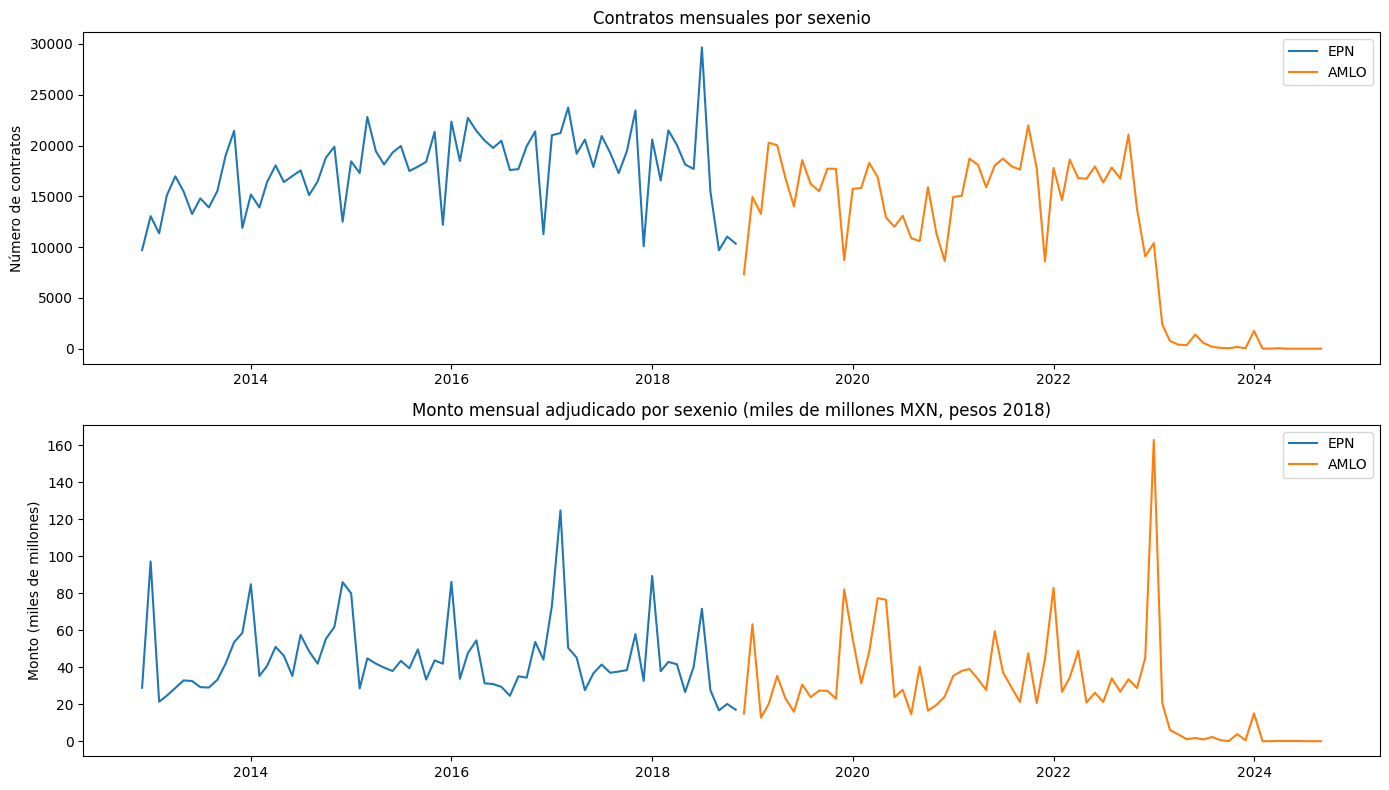

In [17]:
from pyspark.sql.functions import month, sum, count, col, format_number, lpad, concat_ws
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Serie mensual: número de contratos y monto adjudicado
df_ts = df.withColumn("mes", month(col("fecha_inicio")))

serie_mensual = df_ts.groupBy("sexenio", "anio", "mes").agg(
    count("*").alias("num_contratos"),
    sum("importe_real").alias("monto_total")
).orderBy("anio", "mes")

ts_pd = serie_mensual.toPandas()

# Construir fecha como primer día del mes para graficar
ts_pd["fecha"] = pd.to_datetime(
    ts_pd["anio"].astype(str) + "-" + ts_pd["mes"].astype(str).str.zfill(2) + "-01"
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for s, color in [("EPN", "#1f77b4"), ("AMLO", "#ff7f0e")]:
    subset = ts_pd[ts_pd["sexenio"] == s].sort_values("fecha")
    axes[0].plot(subset["fecha"], subset["num_contratos"], label=s, color=color)
    axes[1].plot(subset["fecha"], subset["monto_total"] / 1e9, label=s, color=color)

axes[0].set_title("Contratos mensuales por sexenio")
axes[0].set_ylabel("Número de contratos")
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

axes[1].set_title("Monto mensual adjudicado por sexenio (miles de millones MXN, pesos 2018)")
axes[1].set_ylabel("Monto (miles de millones)")
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

### Regresión temporal con variable dummy por sexenio

Modelo 1 — Tendencia temporal simple
  β₀ (intercepto) =      493,559,041,486  |  p = 0.0005
  β₁ (tendencia)  =      -16,087,583,483  |  p = 0.2899
  R²              = 0.1010
  → Tendencia NO significativa (α=0.05)

Modelo 2 — Cambio estructural (dummy de sexenio)
                            OLS Regression Results                            
Dep. Variable:            monto_total   R-squared:                       0.488
Model:                            OLS   Adj. R-squared:                  0.317
Method:                 Least Squares   F-statistic:                     2.859
Date:                Fri, 10 Apr 2026   Prob (F-statistic):             0.0968
Time:                        02:25:44   Log-Likelihood:                -351.67
No. Observations:                  13   AIC:                             711.3
Df Residuals:                       9   BIC:                             713.6
Df Model:                           3                                         
Covariance Type:       

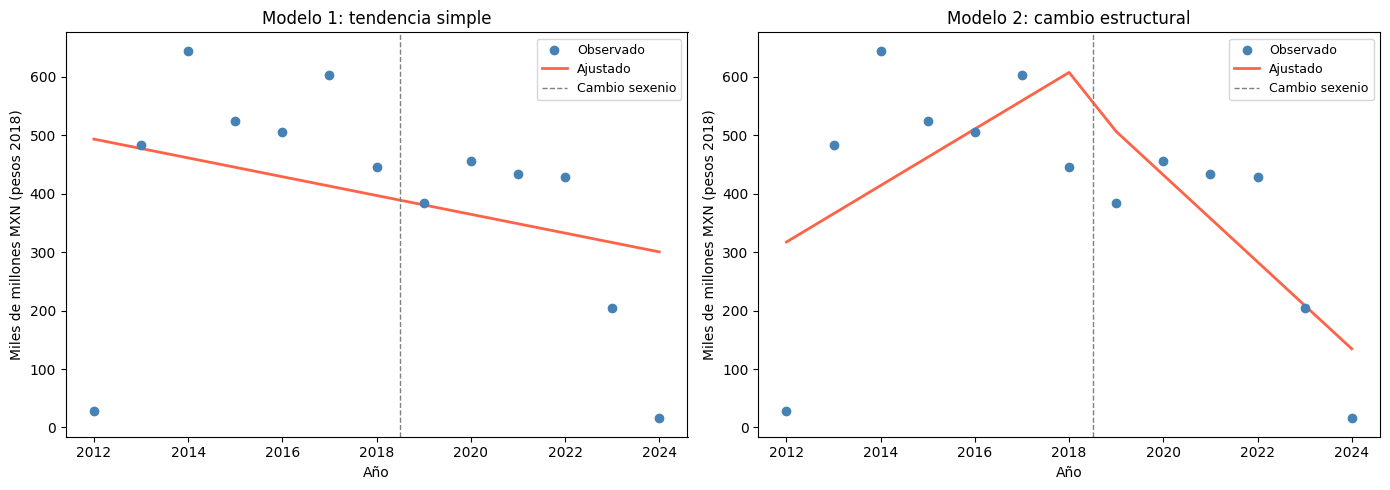

In [18]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pyspark.sql.functions import sum as spark_sum, count, col

# Serie anual
ts_raw = df.groupBy("anio").agg(
    spark_sum("importe_real").alias("monto_total"),
    count("*").alias("num_contratos")
).orderBy("anio").toPandas()

# Variables del modelo
ts_raw["t"]      = ts_raw["anio"] - 2012
ts_raw["D_amlo"] = (ts_raw["anio"] >= 2019).astype(int)
ts_raw["t_amlo"] = ts_raw["t"] * ts_raw["D_amlo"]

y = ts_raw["monto_total"]

# Modelo 1: tendencia simple
X1 = sm.add_constant(ts_raw[["t"]])
m1 = sm.OLS(y, X1).fit()

print("=" * 55)
print("Modelo 1 — Tendencia temporal simple")
print("=" * 55)
print(f"  β₀ (intercepto) = {m1.params['const']:>20,.0f}  |  p = {m1.pvalues['const']:.4f}")
print(f"  β₁ (tendencia)  = {m1.params['t']:>20,.0f}  |  p = {m1.pvalues['t']:.4f}")
print(f"  R²              = {m1.rsquared:.4f}")
print(f"  → Tendencia {'significativa' if m1.pvalues['t'] < 0.05 else 'NO significativa'} (α=0.05)")

# Modelo 2: cambio estructural
X2 = sm.add_constant(ts_raw[["t", "D_amlo", "t_amlo"]])
m2 = sm.OLS(y, X2).fit()

print("\n" + "=" * 55)
print("Modelo 2 — Cambio estructural (dummy de sexenio)")
print("=" * 55)
print(m2.summary())

print("\nInterpretación:")
print(f"  β₁ (tendencia EPN)  = {m2.params['t']:>20,.0f}  p={m2.pvalues['t']:.4f}")
print(f"  D_AMLO              = {m2.params['D_amlo']:>20,.0f}  p={m2.pvalues['D_amlo']:.4f}  → cambio de nivel")
print(f"  t × D_AMLO          = {m2.params['t_amlo']:>20,.0f}  p={m2.pvalues['t_amlo']:.4f}  → cambio de pendiente")


ts_raw["fitted_m1"] = m1.fittedvalues
ts_raw["fitted_m2"] = m2.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col_fit, title in [
    (axes[0], "fitted_m1", "Modelo 1: tendencia simple"),
    (axes[1], "fitted_m2", "Modelo 2: cambio estructural"),
]:
    ax.scatter(ts_raw["anio"], ts_raw["monto_total"] / 1e9,
               color="steelblue", zorder=3, label="Observado")
    ax.plot(ts_raw["anio"], ts_raw[col_fit] / 1e9,
            color="tomato", linewidth=2, label="Ajustado")
    ax.axvline(2018.5, color="gray", linestyle="--", linewidth=1, label="Cambio sexenio")
    ax.set_title(title)
    ax.set_xlabel("Año")
    ax.set_ylabel("Miles de millones MXN (pesos 2018)")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Regresión multivariada

In [19]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# Se toma muestra de 200k registros manteniendo proporción por sexenio
pdf_reg = df.select(
    "importe_real", "sexenio", "duracion_dias", "tipo_procedimiento"
).dropna().sample(fraction=0.10, seed=42).toPandas()

# Variables independientes
pdf_reg["log_importe"]   = np.log1p(pdf_reg["importe_real"])
pdf_reg["D_amlo"]        = (pdf_reg["sexenio"] == "AMLO").astype(int)
pdf_reg["log_duracion"]  = np.log1p(pdf_reg["duracion_dias"].clip(lower=0))

# Dummies de modalidad
dummies = pd.get_dummies(pdf_reg["tipo_procedimiento"], drop_first=True, dtype=float)
pdf_reg = pd.concat([pdf_reg, dummies], axis=1)

vars_x = ["D_amlo", "log_duracion"] + list(dummies.columns)
X = sm.add_constant(pdf_reg[vars_x])
y = pdf_reg["log_importe"]

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

# Diagnóstico de multicolinealidad (VIF)
print("\nFactor de Inflación de la Varianza (VIF):")
vif_data = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif_data[vif_data["Variable"] != "const"].to_string(index=False))
print("\nReferencia: VIF < 5 aceptable | VIF > 10 multicolinealidad grave")

                            OLS Regression Results                            
Dep. Variable:            log_importe   R-squared:                       0.219
Model:                            OLS   Adj. R-squared:                  0.219
Method:                 Least Squares   F-statistic:                 1.152e+04
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        02:26:34   Log-Likelihood:            -4.1936e+05
No. Observations:              205284   AIC:                         8.387e+05
Df Residuals:                  205278   BIC:                         8.388e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 10.3922      0

### Pipeline (random forest)

In [20]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.sql.functions import log1p, month, dayofweek, col

# Features adicionales
df_ml = df.withColumn("log_importe",  log1p(col("importe"))) \
           .withColumn("mes_inicio",   month(col("fecha_inicio"))) \
           .withColumn("dia_semana",   dayofweek(col("fecha_inicio")))

# Limpiar columnas previas si existen
for c in ["label", "tipo_idx", "tipo_ohe", "features"]:
    if c in df_ml.columns:
        df_ml = df_ml.drop(c)

indexer_sexenio = StringIndexer(inputCol="sexenio", outputCol="label")
indexer_tipo    = StringIndexer(inputCol="tipo_contratacion", outputCol="tipo_idx",
                                handleInvalid="keep")
encoder         = OneHotEncoder(inputCols=["tipo_idx"], outputCols=["tipo_ohe"])
assembler       = VectorAssembler(
    inputCols=["log_importe", "duracion_dias", "mes_inicio", "dia_semana", "tipo_ohe"],
    outputCol="features",
    handleInvalid="skip"
)

pipeline = Pipeline(stages=[indexer_sexenio, indexer_tipo, encoder, assembler])
df_ml = pipeline.fit(df_ml).transform(df_ml)
print("Pipeline ejecutado correctamente")

Pipeline ejecutado correctamente


### Random Forest

In [22]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)
from pyspark.sql.functions import col
import pandas as pd
import numpy as np

# --- 1. Split temporal balanceado ---
train = df_ml.filter(
    ((col("sexenio") == "EPN")  & ~col("anio").isin([2017, 2018])) |
    ((col("sexenio") == "AMLO") & ~col("anio").isin([2023, 2024]))
)
test = df_ml.filter(
    ((col("sexenio") == "EPN")  &  col("anio").isin([2017, 2018])) |
    ((col("sexenio") == "AMLO") &  col("anio").isin([2023, 2024]))
)

# --- 2. Balancear el conjunto de entrenamiento con undersampling ---
n_epn_train  = train.filter(col("sexenio") == "EPN").count()
n_amlo_train = train.filter(col("sexenio") == "AMLO").count()
min_clase    = min(n_epn_train, n_amlo_train)
ratio_epn    = min_clase / n_epn_train
ratio_amlo   = min_clase / n_amlo_train

print(f"Train original — EPN: {n_epn_train:,} | AMLO: {n_amlo_train:,}")
print(f"Train balanceado (undersampling) — cada clase: ~{min_clase:,}")

# --- 3. Bootstrap: 5 repeticiones con semillas distintas ---
N_REPS = 5
seeds  = [42, 123, 7, 2024, 99]
metricas_runs = []

for rep, seed in enumerate(seeds, 1):
    # Subsamplear para balancear
    train_epn  = train.filter(col("sexenio") == "EPN").sample(
        fraction=ratio_epn, seed=seed)
    train_amlo = train.filter(col("sexenio") == "AMLO").sample(
        fraction=ratio_amlo, seed=seed)
    train_bal  = train_epn.union(train_amlo)

    rf = RandomForestClassifier(
        labelCol="label", featuresCol="features",
        numTrees=100, maxDepth=8, seed=seed
    )
    model_rep = rf.fit(train_bal)
    pred_rep  = model_rep.transform(test)

    run_metrics = {"seed": seed}
    for metric in ["accuracy", "weightedPrecision", "weightedRecall", "f1"]:
        val = MulticlassClassificationEvaluator(
            labelCol="label", predictionCol="prediction", metricName=metric
        ).evaluate(pred_rep)
        run_metrics[metric] = val

    run_metrics["auc_roc"] = BinaryClassificationEvaluator(
        labelCol="label", rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    ).evaluate(pred_rep)

    print(f"  Rep {rep}: acc={run_metrics['accuracy']:.4f} | "
          f"f1={run_metrics['f1']:.4f} | auc={run_metrics['auc_roc']:.4f}")
    metricas_runs.append(run_metrics)

# --- 4. Resumen: promedio ± desviación estándar ---
df_metricas = pd.DataFrame(metricas_runs)
print("\n" + "=" * 55)
print("RESUMEN BOOTSTRAP (5 repeticiones con datos balanceados)")
print("=" * 55)
for col_m in ["accuracy", "weightedPrecision", "weightedRecall", "f1", "auc_roc"]:
    media = df_metricas[col_m].mean()
    std   = df_metricas[col_m].std()
    print(f"  {col_m:22s}: {media:.4f} ± {std:.4f}")

# --- 5. Matriz de confusión del último modelo (referencia) ---
from pyspark.sql.functions import when
print("\nMatriz de confusión (última repetición):")
pred_rep.withColumn(
    "sexenio_pred",
    when(col("prediction") == 0, "EPN").otherwise("AMLO")
).groupBy("sexenio", "sexenio_pred").count().orderBy("sexenio").show()

# --- 6. Importancia de features (último modelo) ---
feature_names = (
    ["log_importe", "duracion_dias", "mes_inicio", "dia_semana"] +
    [f"tipo_ohe_{i}" for i in range(model_rep.featureImportances.size - 4)]
)
importancias = pd.Series(
    model_rep.featureImportances.toArray(),
    index=feature_names[:model_rep.featureImportances.size]
).sort_values(ascending=False)

print("\nImportancia de features (top 10):")
print(importancias.head(10))

print("""
NOTA INTERPRETATIVA: La importancia de features explica qué características
distinguen a los contratos de un sexenio versus el otro en términos observables,
NO implica causalidad ni permite concluir sobre políticas públicas.
""")

Train original — EPN: 845,167 | AMLO: 763,990
Train balanceado (undersampling) — cada clase: ~763,990
  Rep 1: acc=0.4512 | f1=0.5802 | auc=0.6181
  Rep 2: acc=0.4490 | f1=0.5779 | auc=0.6326
  Rep 3: acc=0.4476 | f1=0.5765 | auc=0.5873
  Rep 4: acc=0.4491 | f1=0.5780 | auc=0.6495
  Rep 5: acc=0.4503 | f1=0.5792 | auc=0.6142

RESUMEN BOOTSTRAP (5 repeticiones con datos balanceados)
  accuracy              : 0.4494 ± 0.0014
  weightedPrecision     : 0.9551 ± 0.0002
  weightedRecall        : 0.4494 ± 0.0014
  f1                    : 0.5784 ± 0.0014
  auc_roc               : 0.6204 ± 0.0231

Matriz de confusión (última repetición):
+-------+------------+------+
|sexenio|sexenio_pred| count|
+-------+------------+------+
|   AMLO|        AMLO| 17561|
|   AMLO|         EPN|  1067|
|    EPN|         EPN|182175|
|    EPN|        AMLO|242742|
+-------+------------+------+


Importancia de features (top 10):
duracion_dias    0.402822
tipo_ohe_2       0.239283
tipo_ohe_4       0.081535
tipo_ohe_

### Clustering k-medias

Calculando inercia para k = 2 a 8 (método del codo)...
  k=2 | inercia=2,643,573 | silhouette=0.5458
  k=3 | inercia=1,922,179 | silhouette=0.5050
  k=4 | inercia=1,469,195 | silhouette=0.5724
  k=5 | inercia=1,388,634 | silhouette=0.4719
  k=6 | inercia=1,011,780 | silhouette=0.5582
  k=7 | inercia=813,893 | silhouette=0.5920
  k=8 | inercia=712,530 | silhouette=0.5731


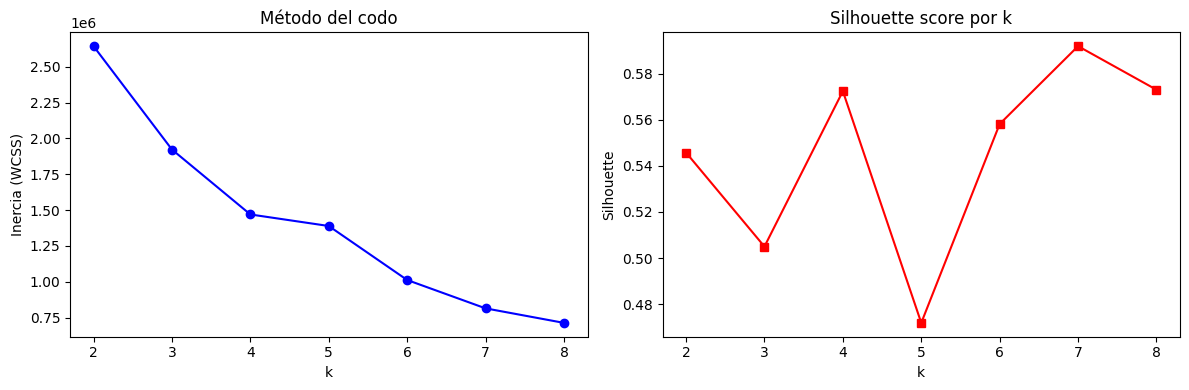


K óptimo: 4 | Silhouette final: 0.5763

Centros de clusters (escala original aproximada):
  Cluster 0: importe≈$304,109 MXN | duración≈309 días
  Cluster 1: importe≈$864,517 MXN | duración≈62 días
  Cluster 2: importe≈$888,184 MXN | duración≈967 días
  Cluster 3: importe≈$30,316 MXN | duración≈41 días

Distribución por cluster:
+----------+------+
|prediction| count|
+----------+------+
|         0|393343|
|         1|642484|
|         2| 36273|
|         3|980602|
+----------+------+


Clusters por sexenio:
+-------+----------+------+
|sexenio|prediction| count|
+-------+----------+------+
|   AMLO|         0|158628|
|   AMLO|         1|215422|
|   AMLO|         2| 17409|
|   AMLO|         3|391159|
|    EPN|         0|234715|
|    EPN|         1|427062|
|    EPN|         2| 18864|
|    EPN|         3|589443|
+-------+----------+------+



In [23]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.sql.functions import log1p, month, col
import matplotlib.pyplot as plt

assembler_k = VectorAssembler(
    inputCols=["log_importe", "duracion_dias"],
    outputCol="features_raw",
    handleInvalid="skip"
)

# *** ESCALADO: obligatorio para K-Means basado en distancias ***
scaler_k = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withStd=True,
    withMean=True
)

df_k = assembler_k.transform(
    df.withColumn("log_importe", log1p(col("importe_real")))
      .dropna(subset=["log_importe", "duracion_dias"])
)
scaler_model_k = scaler_k.fit(df_k)
df_k = scaler_model_k.transform(df_k)

# Método del codo
print("Calculando inercia para k = 2 a 8 (método del codo)...")
inertias = []
silhouettes = []
ks = range(2, 9)

for k in ks:
    km_tmp = KMeans(k=k, seed=42, featuresCol="features_scaled", maxIter=50)
    m_tmp  = km_tmp.fit(df_k)
    inercia = m_tmp.summary.trainingCost
    inertias.append(inercia)

    sil = ClusteringEvaluator(
        featuresCol="features_scaled", metricName="silhouette"
    ).evaluate(m_tmp.transform(df_k))
    silhouettes.append(sil)

    print(f"  k={k} | inercia={inercia:,.0f} | silhouette={sil:.4f}")

# Graficar codo + silhouette juntos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(ks), inertias, "bo-")
ax1.set_xlabel("k"); ax1.set_ylabel("Inercia (WCSS)")
ax1.set_title("Método del codo")

ax2.plot(list(ks), silhouettes, "rs-")
ax2.set_xlabel("k"); ax2.set_ylabel("Silhouette")
ax2.set_title("Silhouette score por k")
plt.tight_layout(); plt.show()

# Elegir k óptimo visualmente y ajustar modelo final
K_OPTIMO = 4  # ajustar según gráficas
km_final   = KMeans(k=K_OPTIMO, seed=42, featuresCol="features_scaled", maxIter=100)
modelo_k   = km_final.fit(df_k)
df_clusters = modelo_k.transform(df_k)

sil_final = ClusteringEvaluator(
    featuresCol="features_scaled", metricName="silhouette"
).evaluate(df_clusters)

print(f"\nK óptimo: {K_OPTIMO} | Silhouette final: {sil_final:.4f}")

import numpy as np
means  = scaler_model_k.mean
stds   = scaler_model_k.std

print("\nCentros de clusters (escala original aproximada):")
for i, c in enumerate(modelo_k.clusterCenters()):
    log_imp_orig = c[0] * stds[0] + means[0]
    dur_orig     = c[1] * stds[1] + means[1]
    imp_orig     = np.expm1(log_imp_orig)
    print(f"  Cluster {i}: importe≈${imp_orig:,.0f} MXN | duración≈{dur_orig:.0f} días")

print("\nDistribución por cluster:")
df_clusters.groupBy("prediction").count().orderBy("prediction").show()

print("\nClusters por sexenio:")
df_clusters.groupBy("sexenio", "prediction").count().orderBy("sexenio", "prediction").show()

### Modelo Logit

In [24]:
import statsmodels.api as sm
from pyspark.sql.functions import col
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Modelo

pdf_logit = df.select(
    "tipo_expediente","importe_real","duracion_dias","anio","sexenio"
).dropna().sample(fraction=0.10, seed=42).toPandas()

pdf_logit["adjudicacion"] = pdf_logit["tipo_expediente"] \
  .str.contains("Adjudicacion directa", na=False).astype(int)

#Transformaciones logaritmicas

pdf_logit["log_importe"]  = np.log1p(pdf_logit["importe_real"].clip(lower=0))
pdf_logit["log_duracion"] = np.log1p(pdf_logit["duracion_dias"].clip(lower=0))
pdf_logit["anio_c"]       = pdf_logit["anio"] - 2018

features = ["log_importe", "log_duracion", "anio_c"]
scaler_logit = StandardScaler()
pdf_logit[features] = scaler_logit.fit_transform(pdf_logit[features])

assert not np.any(np.isinf(pdf_logit[features].values)), "Hay -inf en features"
assert not np.any(np.isnan(pdf_logit[features].values)), "Hay NaN en features"

X = sm.add_constant(pdf_logit[features])
y = pdf_logit["adjudicacion"]

model_logit = sm.Logit(y, X).fit()
print(model_logit.summary())

print("\nEfectos marginales en la media:")
print(model_logit.get_margeff().summary())

print("""
NOTA INTERPRETATIVA: Los coeficientes están en unidades de desviación estándar
(datos escalados), por lo que son directamente comparables entre sí en magnitud.
""")


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packa

         Current function value: 0.000000
         Iterations: 35


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/dis

                           Logit Regression Results                           
Dep. Variable:           adjudicacion   No. Observations:               205284
Model:                          Logit   Df Residuals:                   205280
Method:                           MLE   Df Model:                            3
Date:                Fri, 10 Apr 2026   Pseudo R-squ.:                     inf
Time:                        05:06:10   Log-Likelihood:            -7.3428e-07
converged:                      False   LL-Null:                        0.0000
Covariance Type:            nonrobust   LLR p-value:                     1.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -26.3565   1166.999     -0.023      0.982   -2313.632    2260.919
log_importe   2.623e-13   1240.895   2.11e-16      1.000   -2432.110    2432.110
log_duracion  -1.33e-12   1236.564  -1.08e-1

### Detección de outliers

In [25]:
from pyspark.sql.functions import col, percentile_approx, when
from sklearn.ensemble import IsolationForest
import pandas as pd
import numpy as np

#Detección de outliers
print("DETECCIÓN DE OUTLIERS — método IQR (Spark, escalable)")
# IQR en PySpark
stats = df.select(
    percentile_approx("importe_real", 0.25).alias("q1"),
    percentile_approx("importe_real", 0.75).alias("q3"),
    percentile_approx("duracion_dias", 0.25).alias("q1_dur"),
    percentile_approx("duracion_dias", 0.75).alias("q3_dur")
).collect()[0]

IQR_imp = stats["q3"] - stats["q1"]
IQR_dur = stats["q3_dur"] - stats["q1_dur"]

lower_imp = stats["q1"] - 1.5 * IQR_imp
upper_imp = stats["q3"] + 1.5 * IQR_imp
lower_dur = stats["q1_dur"] - 1.5 * IQR_dur
upper_dur = stats["q3_dur"] + 1.5 * IQR_dur

df_iqr = df.withColumn(
    "outlier_iqr",
    when(
        (col("importe_real") < lower_imp) |
        (col("importe_real") > upper_imp) |
        (col("duracion_dias") < lower_dur) |
        (col("duracion_dias") > upper_dur),
        1
    ).otherwise(0)
)

n_outliers_iqr = df_iqr.filter(col("outlier_iqr") == 1).count()
print(f"\nNúmero de outliers (IQR): {n_outliers_iqr}"
     f"({100*n_outliers_iqr/df.count():.2f}%)")

n_outliers_iqr = df_iqr.filter(col("outlier_iqr") == 1).count()
print(f"\nIQR — Outliers detectados: {n_outliers_iqr:,} "
      f"({100*n_outliers_iqr/df.count():.2f}%)")

# Distribución por sexenio
df_iqr.groupBy("sexenio", "outlier_iqr").count().orderBy("sexenio", "outlier_iqr").show()

# Isolation Forest (muestra)
print("=" * 60)
print("DETECCIÓN DE OUTLIERS — Isolation Forest (muestra 50k)")
print("=" * 60)

pdf_isoforest = df.select("importe_real", "duracion_dias", "sexenio") \
    .dropna().sample(fraction=0.025, seed=42).toPandas()

X_iso = pdf_isoforest[["importe_real", "duracion_dias"]].copy()
X_iso["importe_real"] = np.log1p(X_iso["importe_real"].clip(lower=0))
X_iso["duracion_dias"] = X_iso["duracion_dias"].clip(lower=0)

iso = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
pdf_isoforest["outlier_iso"] = iso.fit_predict(X_iso)  # -1 = outlier, 1 = normal

n_iso = (pdf_isoforest["outlier_iso"] == -1).sum()
print(f"\nIsolation Forest — Outliers en muestra: {n_iso:,} "
      f"({100*n_iso/len(pdf_isoforest):.2f}%)")

print("\nPor sexenio:")
print(
    pdf_isoforest.groupby("sexenio")["outlier_iso"]
    .apply(lambda x: (x == -1).sum())
    .reset_index()
    .rename(columns={"outlier_iso": "n_outliers"})
)

print("""
VENTAJAS frente a Z-score:
  - IQR: no asume normalidad, robusto ante colas pesadas
  - Isolation Forest: multivariado, detecta anomalías en el espacio conjunto
    de importe + duración sin suponer distribución paramétrica
""")


DETECCIÓN DE OUTLIERS — método IQR (Spark, escalable)

Número de outliers (IQR): 357146(17.40%)

IQR — Outliers detectados: 357,146 (17.40%)
+-------+-----------+-------+
|sexenio|outlier_iqr|  count|
+-------+-----------+-------+
|   AMLO|          0| 658912|
|   AMLO|          1| 123706|
|    EPN|          0|1036644|
|    EPN|          1| 233440|
+-------+-----------+-------+

DETECCIÓN DE OUTLIERS — Isolation Forest (muestra 50k)

Isolation Forest — Outliers en muestra: 2,578 (5.00%)

Por sexenio:
  sexenio  n_outliers
0    AMLO        1280
1     EPN        1298

VENTAJAS frente a Z-score:
  - IQR: no asume normalidad, robusto ante colas pesadas
  - Isolation Forest: multivariado, detecta anomalías en el espacio conjunto
    de importe + duración sin suponer distribución paramétrica



### Gráficas

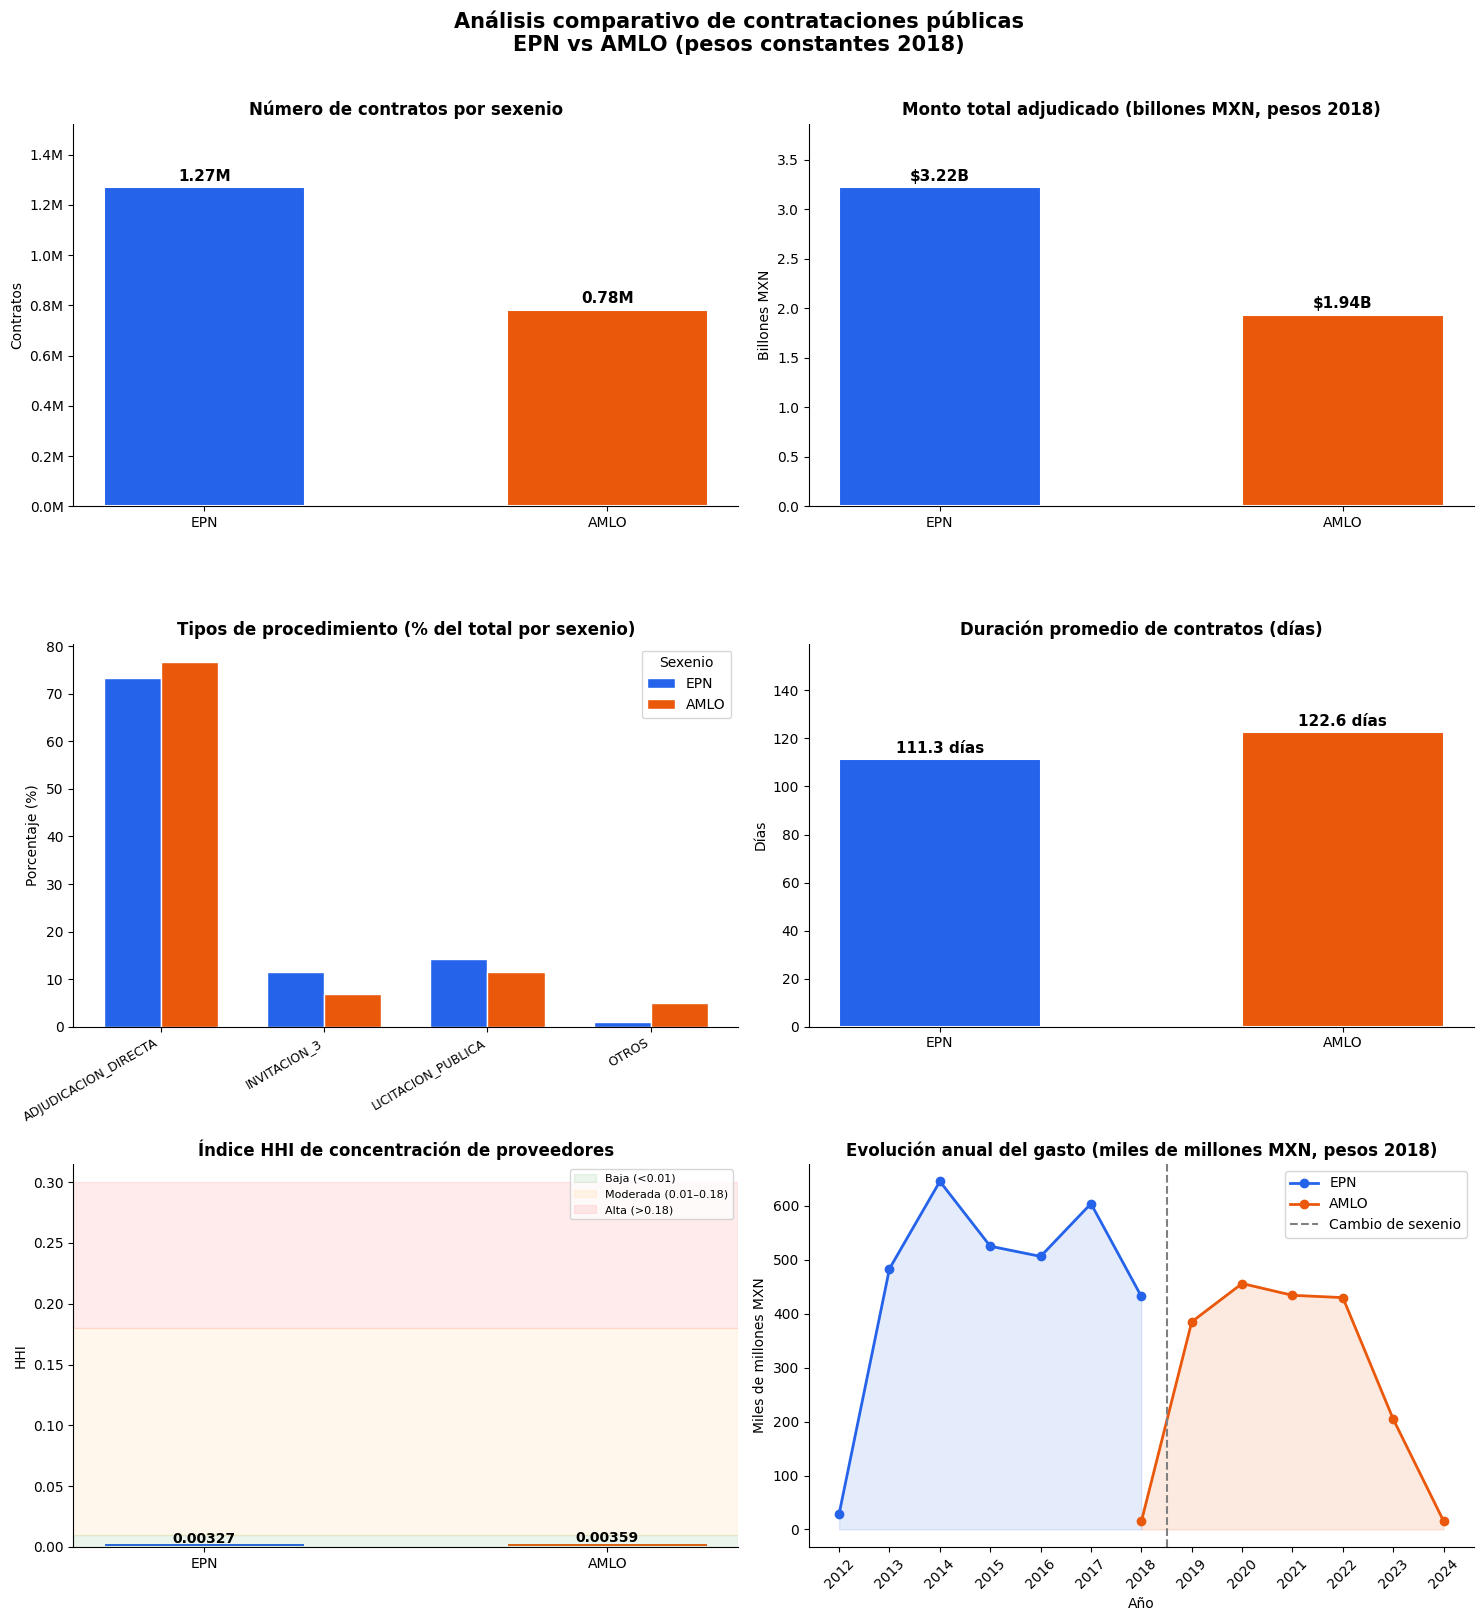

Guardado: visualizaciones_comparativas_v2.png


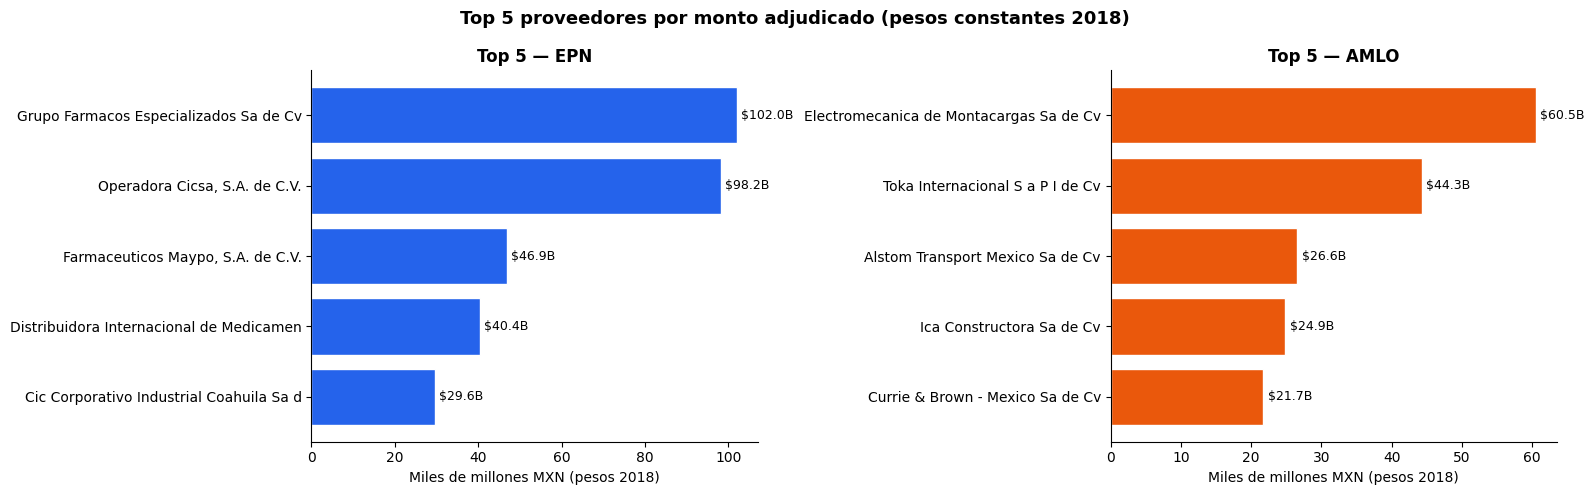

In [26]:

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
from pyspark.sql.functions import sum as spark_sum, avg, pow as spark_pow, col
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

# --- Colores consistentes ---
PALETTE = {"EPN": "#2563EB", "AMLO": "#EA580C"}

# --- Recopilar datos ---
contratos_pd  = df.groupBy("sexenio").count().toPandas()
monto_pd      = df.groupBy("sexenio").agg(spark_sum("importe_real").alias("m")).toPandas()
modalidades_pd = df.groupBy("sexenio", "tipo_procedimiento").count().toPandas()
dura_pd       = df.groupBy("sexenio").agg(avg("duracion_dias").alias("d")).toPandas()

gasto_total = df.groupBy("sexenio").agg(spark_sum("importe_real").alias("gasto_total"))
prov_monto  = df.groupBy("sexenio", "proveedor").agg(spark_sum("importe_real").alias("monto_total"))
prov_part   = prov_monto.join(gasto_total, "sexenio") \
                .withColumn("s_i", col("monto_total") / col("gasto_total"))
hhi_pd      = prov_part.withColumn("s2", spark_pow(col("s_i"), 2)) \
                .groupBy("sexenio").agg(spark_sum("s2").alias("HHI")).toPandas()

ts_anual = df.groupBy("sexenio", "anio").agg(
    spark_sum("importe_real").alias("monto"),
    count("*").alias("n_contratos")
).toPandas()

# --- Figura principal: 3x2 ---
fig, axes = plt.subplots(3, 2, figsize=(15, 16))
fig.suptitle("Análisis comparativo de contrataciones públicas\nEPN vs AMLO (pesos constantes 2018)",
             fontsize=15, fontweight="bold", y=1.01)
axes = axes.flatten()

def fmt_millones(x, _):  return f"{x/1e6:.1f}M"
def fmt_billones(x, _):  return f"{x:.2f}B"

# 1. Número de contratos
orden = ["EPN", "AMLO"]
colores = [PALETTE[s] for s in orden]
vals_c  = [contratos_pd.set_index("sexenio").loc[s, "count"] for s in orden]
bars = axes[0].bar(orden, vals_c, color=colores, width=0.5, edgecolor="white", linewidth=1.5)
axes[0].set_title("Número de contratos por sexenio", fontweight="bold")
axes[0].set_ylabel("Contratos")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_millones))
axes[0].set_ylim(0, max(vals_c) * 1.2)
for bar, v in zip(bars, vals_c):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals_c)*0.02,
                 f"{v/1e6:.2f}M", ha="center", fontsize=11, fontweight="bold")
axes[0].spines[["top", "right"]].set_visible(False)

# 2. Monto total
vals_m = [monto_pd.set_index("sexenio").loc[s, "m"] / 1e12 for s in orden]
bars2  = axes[1].bar(orden, vals_m, color=colores, width=0.5, edgecolor="white", linewidth=1.5)
axes[1].set_title("Monto total adjudicado (billones MXN, pesos 2018)", fontweight="bold")
axes[1].set_ylabel("Billones MXN")
axes[1].set_ylim(0, max(vals_m) * 1.2)
for bar, v in zip(bars2, vals_m):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals_m)*0.02,
                 f"${v:.2f}B", ha="center", fontsize=11, fontweight="bold")
axes[1].spines[["top", "right"]].set_visible(False)

# 3. Modalidades — porcentaje (más informativo que conteo absoluto)
pivot_pct = modalidades_pd.copy()
totales   = pivot_pct.groupby("sexenio")["count"].transform("sum")
pivot_pct["pct"] = 100 * pivot_pct["count"] / totales
pivot_wide = pivot_pct.pivot(index="tipo_procedimiento", columns="sexenio", values="pct").fillna(0)
x = np.arange(len(pivot_wide))
w = 0.35
for i, (sexenio, color) in enumerate([("EPN", PALETTE["EPN"]), ("AMLO", PALETTE["AMLO"])]):
    if sexenio in pivot_wide.columns:
        axes[2].bar(x + i*w, pivot_wide[sexenio], w, label=sexenio, color=color,
                    edgecolor="white", linewidth=1)
axes[2].set_xticks(x + w/2)
axes[2].set_xticklabels(pivot_wide.index, rotation=30, ha="right", fontsize=9)
axes[2].set_title("Tipos de procedimiento (% del total por sexenio)", fontweight="bold")
axes[2].set_ylabel("Porcentaje (%)")
axes[2].legend(title="Sexenio")
axes[2].spines[["top", "right"]].set_visible(False)

# 4. Duración promedio con barras de error (IQR o std si disponible)
vals_d = [dura_pd.set_index("sexenio").loc[s, "d"] for s in orden]
bars4  = axes[3].bar(orden, vals_d, color=colores, width=0.5, edgecolor="white", linewidth=1.5)
axes[3].set_title("Duración promedio de contratos (días)", fontweight="bold")
axes[3].set_ylabel("Días")
axes[3].set_ylim(0, max(vals_d) * 1.3)
for bar, v in zip(bars4, vals_d):
    axes[3].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals_d)*0.02,
                 f"{v:.1f} días", ha="center", fontsize=11, fontweight="bold")
axes[3].spines[["top", "right"]].set_visible(False)

# 5. HHI con zonas de referencia
hhi_vals = [hhi_pd.set_index("sexenio").loc[s, "HHI"] for s in orden]
axes[4].bar(orden, hhi_vals, color=colores, width=0.5, edgecolor="white", linewidth=1.5)
axes[4].axhspan(0,    0.01, alpha=0.08, color="green",  label="Baja (<0.01)")
axes[4].axhspan(0.01, 0.18, alpha=0.08, color="orange", label="Moderada (0.01–0.18)")
axes[4].axhspan(0.18, 0.30, alpha=0.08, color="red",    label="Alta (>0.18)")
axes[4].set_title("Índice HHI de concentración de proveedores", fontweight="bold")
axes[4].set_ylabel("HHI")
axes[4].legend(fontsize=8, loc="upper right")
axes[4].spines[["top", "right"]].set_visible(False)
for i, (s, v) in enumerate(zip(orden, hhi_vals)):
    axes[4].text(i, v + 0.0001, f"{v:.5f}", ha="center", fontsize=10, fontweight="bold")

# 6. Evolución anual — líneas con área sombreada
for s, c in [("EPN", PALETTE["EPN"]), ("AMLO", PALETTE["AMLO"])]:
    sub = ts_anual[ts_anual["sexenio"] == s].sort_values("anio")
    axes[5].plot(sub["anio"], sub["monto"]/1e9, label=s, color=c, marker="o", linewidth=2)
    axes[5].fill_between(sub["anio"], sub["monto"]/1e9, alpha=0.12, color=c)
axes[5].axvline(2018.5, color="gray", linestyle="--", linewidth=1.5, label="Cambio de sexenio")
axes[5].set_title("Evolución anual del gasto (miles de millones MXN, pesos 2018)", fontweight="bold")
axes[5].set_ylabel("Miles de millones MXN")
axes[5].set_xlabel("Año")
axes[5].legend()
axes[5].spines[["top", "right"]].set_visible(False)
axes[5].set_xticks(ts_anual["anio"].unique())
axes[5].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("visualizaciones_comparativas_v2.png", dpi=180, bbox_inches="tight")
plt.show()
print("Guardado: visualizaciones_comparativas_v2.png")

# --- Top 5 proveedores mejorado ---
window_prov = Window.partitionBy("sexenio").orderBy(col("monto_total").desc())
top5_pd = prov_monto.withColumn("rank", row_number().over(window_prov)) \
    .filter(col("rank") <= 5).toPandas()

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5))
fig2.suptitle("Top 5 proveedores por monto adjudicado (pesos constantes 2018)",
              fontsize=13, fontweight="bold")

for ax, sexenio in zip(axes2, ["EPN", "AMLO"]):
    sub     = top5_pd[top5_pd["sexenio"] == sexenio].sort_values("monto_total")
    nombres = sub["proveedor"].str[:40]
    vals    = sub["monto_total"] / 1e9
    bars_h  = ax.barh(nombres, vals, color=PALETTE[sexenio], edgecolor="white", linewidth=1)
    for bar, v in zip(bars_h, vals):
        ax.text(v + max(vals)*0.01, bar.get_y() + bar.get_height()/2,
                f"${v:.1f}B", va="center", fontsize=9)
    ax.set_title(f"Top 5 — {sexenio}", fontweight="bold")
    ax.set_xlabel("Miles de millones MXN (pesos 2018)")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("top_proveedores_v2.png", dpi=180, bbox_inches="tight")
plt.show()